# Lezione 24 — Decadimento temporale: quanto conta ancora una memoria vecchia

**Come si usa questo notebook.** Come sempre. Prerequisito: Lezione 23
(`PARAMETRI_TIPO`, con un half-life dichiarato per ciascun type). Oggi
quell'half-life diventa una formula eseguibile: un punteggio di
**recency** che dice quanto conta ancora, oggi, una memoria registrata nel
passato.

**Cosa saprai fare alla fine:** implementare il decadimento esponenziale
con half-life, spiegare perche' un riferimento temporale fisso e
dichiarato e' necessario per la riproducibilita', e calcolare la recency
di ogni memoria del progetto usando i parametri per type della Lezione
23.

## Parte 1 — Teoria: decadimento esponenziale e half-life

Il **decadimento esponenziale** e' il modello standard per "quanto conta
ancora qualcosa dopo un certo tempo": il punteggio si dimezza a ogni
intervallo fisso di tempo (l'**half-life**), invece di scendere di una
quantita' fissa. La formula:

```
recency(eta) = 0.5 ** (eta / half_life)
```

dove `eta` e' il tempo trascorso dalla registrazione della memoria (in
giorni, qui) e `half_life` e' il parametro per type della Lezione 23. Tre
proprieta' che rendono questa formula la scelta giusta rispetto a un
decadimento lineare (`1 - eta/costante`):

- a `eta = 0`, `recency = 1.0` (una memoria appena registrata conta al
  massimo);
- a `eta = half_life`, `recency = 0.5` **per costruzione** (e' la
  definizione stessa di half-life: verificherai questa proprieta'
  nell'esercizio);
- `recency` non scende mai sotto zero e non si azzera mai del tutto (a
  differenza di un decadimento lineare, che a un certo punto diventa
  negativo e va troncato a mano) — un fatto vecchissimo conta pochissimo,
  ma non "smette di esistere" nel punteggio.

**Un dettaglio che conta per la riproducibilita':** calcolare `eta`
richiede un "adesso" — ma un sistema reale usa l'orologio di sistema
(`datetime.now()`), che cambia **ogni volta che esegui il notebook**,
rendendo impossibile confrontare due esecuzioni o scrivere un `assert` che
non si rompa domani. Qui fissiamo un riferimento temporale **dichiarato**
(`ORA_RIFERIMENTO`, una costante), esattamente come nelle lezioni con reti
neurali si fissa un seed (`keras.utils.set_random_seed(42)`) per rendere
l'esecuzione ripetibile: lo stesso principio di riproducibilita' applicato
al tempo invece che alla casualita'.

In [1]:
import pandas as pd
import numpy as np

ORA_RIFERIMENTO = pd.Timestamp('2026-07-18')  # fissato, non datetime.now(): vedi nota sopra


def recency_score(timestamp, half_life_giorni, ora=ORA_RIFERIMENTO):
    eta_giorni = (ora - pd.Timestamp(timestamp)).total_seconds() / 86400
    return 0.5 ** (eta_giorni / half_life_giorni)


memoria_recente = recency_score('2026-07-10', half_life_giorni=30)   # 8 giorni fa
memoria_vecchia = recency_score('2026-01-10', half_life_giorni=30)   # ~189 giorni fa
print(f'memoria di 8 giorni fa, half-life 30gg  : {memoria_recente:.3f}')
print(f'memoria di ~189 giorni fa, half-life 30gg: {memoria_vecchia:.3f}')

memoria di 8 giorni fa, half-life 30gg  : 0.831
memoria di ~189 giorni fa, half-life 30gg: 0.013


Leggi l'output: una memoria di 8 giorni (poco piu' di un quarto
dell'half-life di 30 giorni) mantiene un punteggio alto ma gia' inferiore
a 1; una memoria di circa 189 giorni (piu' di 6 half-life) e' quasi
azzerata, senza pero' toccare esattamente zero.

## Parte 2 — Esercizio guidato

Il tuo compito: verifica **la proprieta' che definisce l'half-life**.
Calcola `recency_score` per una memoria con eta' esattamente uguale a
`half_life_giorni=30` (cioe' una data 30 giorni prima di
`ORA_RIFERIMENTO`) e controlla che il risultato sia `0.5`.

In [2]:
# Scrivi qui: calcola la data 30 giorni prima di ORA_RIFERIMENTO
# (pd.Timedelta(days=30)), chiama recency_score con half_life_giorni=30
# e verifica che il risultato sia (quasi) 0.5.

pass

### Soluzione spiegata

Una memoria con eta' esattamente pari all'half-life deve avere
`recency = 0.5 ** (half_life / half_life) = 0.5 ** 1 = 0.5` — non e' una
coincidenza empirica, e' la **definizione** di half-life applicata alla
formula: verificarlo con un `assert` conferma che l'implementazione segue
davvero la definizione, non solo "assomiglia" a un decadimento.

In [3]:
data_a_half_life = ORA_RIFERIMENTO - pd.Timedelta(days=30)
punteggio = recency_score(data_a_half_life, half_life_giorni=30)
print(f'recency a eta = half_life: {punteggio:.6f}')
assert abs(punteggio - 0.5) < 1e-9

recency a eta = half_life: 0.500000


## Parte 3 — Il progetto: Memory AI Lab, passo 24 — recency per ogni memoria

Applichiamo `recency_score` a tutto il train set, usando l'half-life
**per type** della Lezione 23 (non uno unico per tutte le memorie): una
memoria episodic di 60 giorni e una semantic di 60 giorni devono avere
recency molto diverse, proprio perche' i due type hanno half-life
diversi.

In [4]:
from pathlib import Path

processed = Path('..') / 'datasets' / 'processed'
train = pd.read_csv(processed / 'memory_train.csv')

PARAMETRI_TIPO = {
    'episodic':   {'half_life_giorni': 30},
    'semantic':   {'half_life_giorni': 365},
    'preference': {'half_life_giorni': 180},
    'unknown':    {'half_life_giorni': 60},
}

train['half_life_giorni'] = train['type'].map(lambda t: PARAMETRI_TIPO[t]['half_life_giorni'])
train['recency'] = train.apply(
    lambda riga: recency_score(riga['timestamp'], riga['half_life_giorni']), axis=1)

print(train.groupby('type')['recency'].agg(['mean', 'min', 'max']).round(3))

             mean    min    max
type                           
episodic    0.209  0.084  0.401
preference  0.741  0.661  0.853
semantic    0.871  0.818  0.925
unknown     0.388  0.388  0.388


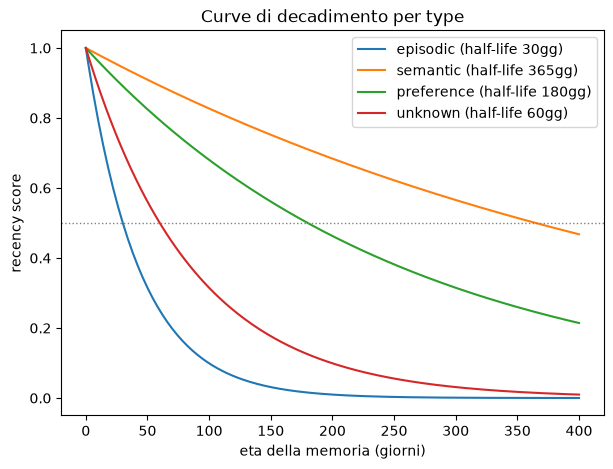

In [5]:
import matplotlib.pyplot as plt

eta_range = np.linspace(0, 400, 200)
fig, ax = plt.subplots(figsize=(7, 5))
for tipo, parametri in PARAMETRI_TIPO.items():
    curva = 0.5 ** (eta_range / parametri['half_life_giorni'])
    ax.plot(eta_range, curva, label=f"{tipo} (half-life {parametri['half_life_giorni']}gg)")
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('eta della memoria (giorni)')
ax.set_ylabel('recency score')
ax.set_title('Curve di decadimento per type')
ax.legend()
plt.show()

Guarda il grafico: la curva `episodic` (half-life 30gg) scende ripida e
tocca 0.5 molto prima delle altre; `semantic` (half-life 365gg) resta alta
per l'intero intervallo mostrato, coerente con l'idea che un fatto
generale non perde rilevanza solo perche' e' passato del tempo. La tabella
sopra lo conferma sui dati veri: le memorie `episodic` del train (eta'
media ~74 giorni, ben oltre il loro half-life di 30) hanno recency media
attorno a 0.2, mentre le `semantic` (stesso range di eta', half-life di
365) restano sopra 0.85 — la stessa eta' anagrafica, punteggi molto
diversi, esattamente perche' il half-life e' diverso.

## Cosa hai imparato

- Il **decadimento esponenziale** (`0.5 ** (eta / half_life)`) e' la
  formula standard per "quanto conta ancora oggi qualcosa del passato": a
  `eta = half_life` il punteggio e' sempre `0.5`, per definizione.
- Un riferimento temporale **fisso e dichiarato** (non
  `datetime.now()`) e' necessario per la riproducibilita' — lo stesso
  principio dei seed nelle reti neurali, applicato al tempo.
- Half-life diversi per type (Lezione 23) producono curve di decadimento
  molto diverse a parita' di eta' anagrafica: e' il punto dell'aver
  differenziato i parametri per type, non solo una scelta estetica.

## Quiz

1. Perche' `recency(eta=half_life) = 0.5` e' una proprieta' garantita
   dalla formula, non un caso osservato sui dati?
2. Perche' questo notebook usa `ORA_RIFERIMENTO = pd.Timestamp('2026-07-18')`
   invece di `pd.Timestamp.now()`?
3. Due memorie hanno la stessa eta' (60 giorni) ma type diversi
   (`episodic` e `semantic`). Perche' la loro recency puo' essere molto
   diversa anche se l'eta' e' identica?

<details>
<summary><b>Apri le risposte</b></summary>

1. Perche' sostituendo `eta = half_life` nella formula si ottiene
   algebricamente `0.5 ** (half_life / half_life) = 0.5 ** 1 = 0.5`,
   indipendentemente dai dati: e' una conseguenza diretta della
   definizione di half-life, verificabile con un `assert` come nella
   Parte 2, non una coincidenza da controllare empiricamente.
2. Perche' `datetime.now()` cambia a ogni esecuzione, rendendo impossibile
   confrontare due run dello stesso notebook o scrivere un `assert` che
   resti valido nel tempo — lo stesso motivo per cui le lezioni con reti
   neurali fissano un seed: la riproducibilita' richiede che tutte le
   fonti di variazione (casualita', tempo) siano dichiarate esplicitamente.
3. Perche' `recency` dipende sia dall'eta' sia dall'half-life, e i due
   type hanno half-life diversi (30 giorni per episodic, 365 per
   semantic, Lezione 23): alla stessa eta' di 60 giorni, episodic ha gia'
   superato il suo half-life (recency sotto 0.5), mentre semantic e'
   ancora lontanissimo dal suo (recency vicina a 1).
</details>

## Fonti

- Wikipedia, *Exponential decay* (definizione generale del modello
  matematico usato in questa lezione):
  https://en.wikipedia.org/wiki/Exponential_decay
- Wikipedia, *Half-life* (definizione formale della proprieta' verificata
  nell'esercizio):
  https://en.wikipedia.org/wiki/Half-life
- pandas, `Timestamp` e aritmetica di date/timedelta (usati per
  `ORA_RIFERIMENTO` ed `eta_giorni`):
  https://pandas.pydata.org/docs/reference/api/pandas.Timestamp.html

L'applicazione del decadimento ai type del Memory AI Lab (half-life per
type, `ORA_RIFERIMENTO` fisso) e' una scelta di design per il progetto,
non da una fonte esterna.

## Prossima lezione

`recency` e' un solo ingrediente. La prossima lezione lo combina con il
campo `importance` (Lezione 1) e il peso di type (Lezione 23) in un unico
**punteggio di importanza composito**.